Training samples: 107
Testing samples: 27

TRAINING BIDIRECTIONAL RNN
Epoch 20/100, Loss: 0.00402
Epoch 40/100, Loss: 0.00186
Epoch 60/100, Loss: 0.00200
Epoch 80/100, Loss: 0.00266
Epoch 100/100, Loss: 0.00216

TRAINING FEEDFORWARD NN
Epoch 20/100, Loss: 0.00203
Epoch 40/100, Loss: 0.00153
Epoch 60/100, Loss: 0.00100
Epoch 80/100, Loss: 0.00089
Epoch 100/100, Loss: 0.00075


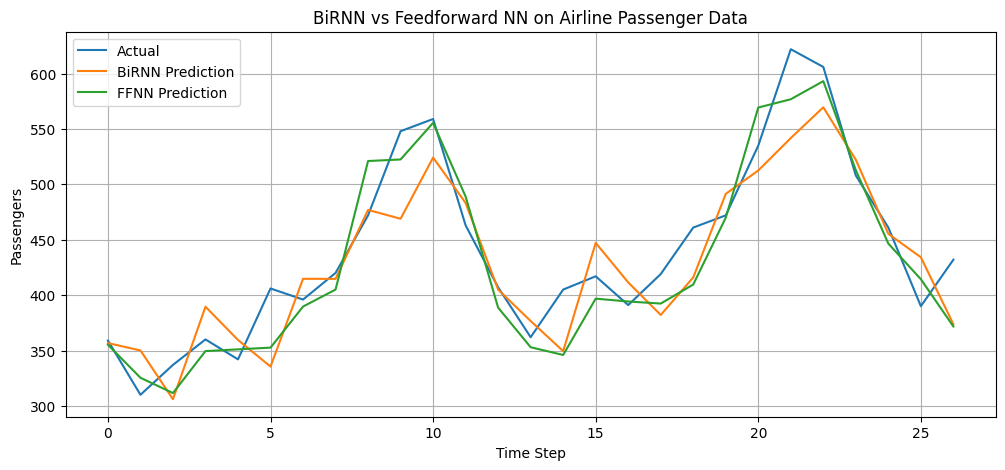


FINAL RESULTS
BiRNN MSE: 1453.573
FFNN MSE: 869.653

FFNN achieved lower MSE.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# STEP 1: Load and Prepare Airline Passenger Dataset
# ============================================================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-airline-passengers.csv"

df = pd.read_csv(
    url,
    usecols=[1]
)

data = df.values.astype("float32")


# Scale data between 0 and 1
scaler = MinMaxScaler(
    feature_range=(0, 1)
)

data_scaled = scaler.fit_transform(data)


# ============================================================
# STEP 2: Create Sequences
# ============================================================

SEQ_LENGTH = 10

X = np.array([
    data_scaled[i:i + SEQ_LENGTH]
    for i in range(
        len(data_scaled) - SEQ_LENGTH
    )
])

y = np.array([
    data_scaled[i + SEQ_LENGTH]
    for i in range(
        len(data_scaled) - SEQ_LENGTH
    )
])


# Split into training and testing data
train_size = int(
    len(X) * 0.8
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# STEP 3: Convert Data into PyTorch Tensors
# ============================================================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)


# Create DataLoader
train_loader = DataLoader(
    TensorDataset(
        X_train_tensor,
        y_train_tensor
    ),
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(
        X_test_tensor,
        y_test_tensor
    ),
    batch_size=1,
    shuffle=False
)


# ============================================================
# STEP 4: Define Bidirectional RNN
# ============================================================

class BiRNN(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=1
    ):

        super(BiRNN, self).__init__()

        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(
            hidden_size * 2,
            1
        )


    def forward(self, x):

        out, _ = self.rnn(x)

        # Take output from last time step
        out = out[:, -1, :]

        return self.fc(out)


# ============================================================
# STEP 5: Define Feedforward Neural Network
# ============================================================

class FeedforwardNN(nn.Module):

    def __init__(
        self,
        input_size
    ):

        super(FeedforwardNN, self).__init__()

        self.fc1 = nn.Linear(
            input_size,
            64
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            1
        )


    def forward(self, x):

        # Flatten sequence
        x = x.view(
            x.size(0),
            -1
        )

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x


# ============================================================
# STEP 6: Training Function
# ============================================================

def train_model(
    model,
    loader,
    epochs=100
):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    model.train()

    for epoch in range(epochs):

        loss_epoch = 0.0

        for seqs, targets in loader:

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(seqs)

            # Calculate loss
            loss = criterion(
                outputs,
                targets
            )

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            loss_epoch += loss.item()


        # Display loss every 20 epochs
        if (epoch + 1) % 20 == 0:

            average_loss = (
                loss_epoch / len(loader)
            )

            print(
                f"Epoch {epoch + 1}/100, "
                f"Loss: {average_loss:.5f}"
            )


# ============================================================
# STEP 7: Evaluation Function
# ============================================================

def evaluate_model(
    model,
    X
):

    model.eval()

    with torch.no_grad():

        predictions = model(X)

    return predictions.numpy()


# ============================================================
# STEP 8: Train BiRNN
# ============================================================

print("\n==============================")
print("TRAINING BIDIRECTIONAL RNN")
print("==============================")

birnn = BiRNN()

train_model(
    birnn,
    train_loader,
    epochs=100
)


# ============================================================
# STEP 9: Train Feedforward NN
# ============================================================

print("\n==============================")
print("TRAINING FEEDFORWARD NN")
print("==============================")

ffnn = FeedforwardNN(
    input_size=SEQ_LENGTH
)

train_model(
    ffnn,
    train_loader,
    epochs=100
)


# ============================================================
# STEP 10: Make Predictions
# ============================================================

pred_birnn = evaluate_model(
    birnn,
    X_test_tensor
)

pred_ffnn = evaluate_model(
    ffnn,
    X_test_tensor
)


# ============================================================
# STEP 11: Inverse Transform Predictions
# ============================================================

pred_birnn_inv = scaler.inverse_transform(
    pred_birnn
)

pred_ffnn_inv = scaler.inverse_transform(
    pred_ffnn
)

y_test_inv = scaler.inverse_transform(
    y_test
)


# ============================================================
# STEP 12: Plot Actual vs Predictions
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    y_test_inv,
    label="Actual"
)

plt.plot(
    pred_birnn_inv,
    label="BiRNN Prediction"
)

plt.plot(
    pred_ffnn_inv,
    label="FFNN Prediction"
)

plt.legend()

plt.title(
    "BiRNN vs Feedforward NN on Airline Passenger Data"
)

plt.xlabel(
    "Time Step"
)

plt.ylabel(
    "Passengers"
)

plt.grid(True)

plt.show()


# ============================================================
# STEP 13: Calculate MSE
# ============================================================

mse_birnn = mean_squared_error(
    y_test_inv,
    pred_birnn_inv
)

mse_ffnn = mean_squared_error(
    y_test_inv,
    pred_ffnn_inv
)


# Display results
print("\n==============================")
print("FINAL RESULTS")
print("==============================")

print(
    f"BiRNN MSE: {mse_birnn:.3f}"
)

print(
    f"FFNN MSE: {mse_ffnn:.3f}"
)


# Compare models
if mse_birnn < mse_ffnn:

    print(
        "\nBiRNN achieved lower MSE."
    )

else:

    print(
        "\nFFNN achieved lower MSE."
    )